In [1]:
import jax
from jax import config
import jax.numpy as jnp
import jax_dataloader as jd

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import os

from torch.utils.data import Dataset

# JAX environment setup
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

Dataset summary:
<xarray.Dataset> Size: 3GB
Dimensions:   (sample: 10000, x: 128, y: 128)
Coordinates:
  * x         (x) float64 1kB 0.0 0.007874 0.01575 0.02362 ... 0.9843 0.9921 1.0
  * y         (y) float64 1kB 0.0 0.007874 0.01575 0.02362 ... 0.9843 0.9921 1.0
Dimensions without coordinates: sample
Data variables:
    solution  (sample, x, y) float64 1GB ...
    source    (sample, x, y) float64 1GB ...
Attributes:
    description:         2D Helmholtz Equation Dataset with Sinusoidal Superp...
    equation:            (nabla^2 + k)u = q
    n_max_terms:         5
    boundary_condition:  Homogeneous Dirichlet (u=0)

Extracted Source Shape: (128, 128) | dtype: float64
Extracted Solution Shape: (128, 128) | dtype: float64


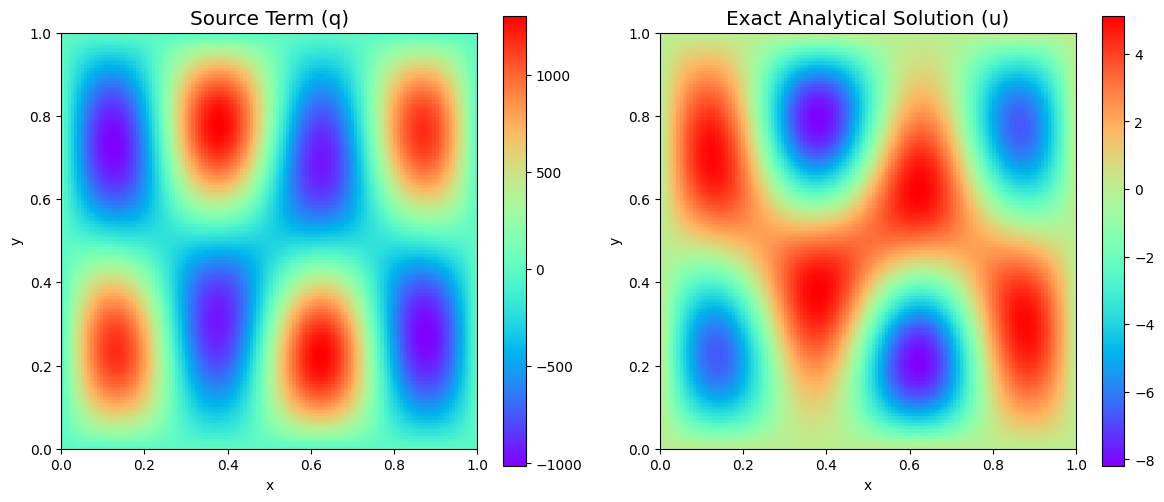

In [12]:
DATA_DIR = Path.cwd().parent.parent / "data"
FILE_PATH = DATA_DIR / "Helmholtz-Sinusoidal.nc"

ds = xr.open_dataset(FILE_PATH)
print(f"Dataset summary:\n{ds}\n")

# Extract a random sample to visualize the superimposed waves
sample_idx = 3 # 285

source_sample = ds['source'][sample_idx].values
solution_sample = ds['solution'][sample_idx].values

print(f"Extracted Source Shape: {source_sample.shape} | dtype: {source_sample.dtype}")
print(f"Extracted Solution Shape: {solution_sample.shape} | dtype: {solution_sample.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Define the physical bounds of your grid: [x_min, x_max, y_min, y_max]
domain_extent = [0.0, 1.0, 0.0, 1.0]

# Plot Source (q)
im1 = axes[0].imshow(source_sample.T, origin='lower', cmap='rainbow', extent=domain_extent)
fig.colorbar(im1, ax=axes[0])
axes[0].set_title('Source Term (q)', fontsize='x-large')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Plot Solution (u)
im2 = axes[1].imshow(solution_sample.T, origin='lower', cmap='rainbow', extent=domain_extent)
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Exact Analytical Solution (u)', fontsize='x-large')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

In [ ]:
class HelmholtzDataset(Dataset):
    def __init__(self, source_data, solution_data):
        # Reshape (N, 128, 128) to (N, 16384, 1)
        self.s = source_data.reshape(source_data.shape[0], -1, 1)
        self.u = solution_data.reshape(solution_data.shape[0], -1, 1)

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.s[idx], self.u[idx]

all_source = ds['source'].values
all_solution = ds['solution'].values
ds.close()

n_train = 9640
n_val = 120
n_test = 240

train_dataset = HelmholtzDataset(
    source_data=all_source[:n_train], 
    solution_data=all_solution[:n_train], 
)

val_dataset = HelmholtzDataset(
    source_data=all_source[n_train : n_train + n_val], 
    solution_data=all_solution[n_train : n_train + n_val], 
)

test_dataset = HelmholtzDataset(
    source_data=all_source[-n_test:], 
    solution_data=all_solution[-n_test:], 
)

batch_size_samples = 32
train_dataloader = jd.DataLoader(
    train_dataset, backend='pytorch', batch_size=batch_size_samples, 
    shuffle=True, drop_last=True, num_workers=0
)

val_dataloader = jd.DataLoader(
    val_dataset, backend='pytorch', batch_size=batch_size_samples, 
    shuffle=False, num_workers=0 
)

print("DataLoaders ready for training loop!")

In [ ]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)

X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

# Dirichlet Boundary Condition Logic
x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

x_bc = x[bc_all]
y_bc = y[bc_all]

# Since we generated with pure sine waves, boundaries are mathematically guaranteed to be 0
u_bc = jnp.zeros_like(x_bc) 

print(f"Total interior PDE points: {x.shape[0]}")
print(f"Total boundary points: {x_bc.shape[0]}")